# Tugas 2: Text Preprocessing, Vector Space Model (VSM), TF-IDF, dan Reduksi Dimensi PCA

Notebook Tugas 2 ini mengolah hasil penarikan (*crawling*) berita dari Tugas 1 — sebanyak 200 artikel dari Detik.com (100 artikel kategori *Sport* dan 100 artikel kategori *Finance*) — menjadi korpus bersih, representasi ruang vektor (*Vector Space Model* / TF-IDF), dan reduksi dimensi dengan PCA yang siap digunakan untuk pemodelan klasifikasi pada **Tugas 3**.

## Alur Kerja (Workflow Outline)

Pipeline pengolahan teks tersusun secara runtut dan sistematis ke dalam 4 tahap utama:
1. **Tahap 1: Memuat Data & Eksplorasi Awal (*Data & Exploration*)** — Memeriksa struktur dataset, kelengkapan data (*completeness check*), serta distribusi panjang teks per label.
2. **Tahap 2: Pembersihan Format & Analisis Kebahasaan (*Cleaning & Language*)** — Deteksi dan normalisasi karakter non-ASCII, analisis sensus token 1–2 huruf, serta deteksi bahasa asing pada tingkat kalimat dan token.
3. **Tahap 3: Pelestarian Makna & Standardisasi Slang (*Meaning Preservation*)** — Melindungi entitas komposit (URL, lambang mata uang, istilah olahraga, angka Romawi), sensus kata kapital/nama diri, standardisasi bahasa gaul secara terarah, dan penyusunan korpus bersih akhir.
4. **Tahap 4: Representasi VSM, TF-IDF, dan Reduksi Dimensi (*Representation & Reduction*)** — Ekstraksi kosakata unik tiap kategori, pembentukan matriks TF-IDF (penuh 6.202 fitur dan tereduksi 500 fitur) dengan kolom label di akhir, serta reduksi dimensi PCA ke dalam 2 komponen utama untuk visualisasi sebaran data.


## Tahap 1: Memuat Data & Eksplorasi Awal (Data & Exploration)

### 1.1 Membaca Dataset Berita
Data dibaca langsung dari berkas CSV hasil crawl. Pemeriksaan awal difokuskan pada integritas struktur tabel sebelum masuk ke tingkat teks.

### 1.2 Struktur Data (Data Structure)
Ukuran dan bentuk dataset diperiksa lebih dulu: jumlah baris dokumen dan kolom atribut yang tersedia.


In [1]:
import pandas as pd
import os

csv_path = "data/crawling_detik.csv" if os.path.exists("data/crawling_detik.csv") else "../data/crawling_detik.csv"
df = pd.read_csv(csv_path)
print("Ukuran dataset (baris, kolom):", df.shape)
df.info()

Ukuran dataset (baris, kolom): (200, 4)
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   id          200 non-null    int64
 1   isi_berita  200 non-null    str  
 2   label       200 non-null    str  
 3   url         200 non-null    str  
dtypes: int64(1), str(3)
memory usage: 6.4 KB


Lima baris pertama memperlihatkan struktur tiap kolom: `id`, `isi_berita`, `label` (`sport` dan `finance`), serta tautan sumber `url`.


In [2]:
df.head()

,id,isi_berita,label,url
0,1,Persatuan Bulutangkis Indonesia (PBSI) baru sa...,sport,https://sport.detik.com/raket/d-8600001/berita-1
1,2,"Tunggal putra Indonesia, Jonatan Christie, men...",sport,https://sport.detik.com/raket/d-8600002/berita-2
2,3,Sabar Karyaman Gutama/Moh Reza Pahlevi Isfahan...,sport,https://sport.detik.com/raket/d-8600003/berita-3
3,4,Dua petenis Indonesia menyusul Nathan Barki lo...,sport,https://sport.detik.com/raket/d-8600004/berita-4
4,5,Babak utama Seri IV M-15 Men's World Tennis Ch...,sport,https://sport.detik.com/raket/d-8600005/berita-5


### 1.3 Pemeriksaan Kelengkapan Data (Completeness Check)
Kelengkapan data diperiksa secara menyeluruh: total baris, keberadaan nilai kosong (*missing values*), baris duplikat, dan keseimbangan jumlah dokumen pada tiap label kategori.


In [3]:
checks = pd.DataFrame({
    "pemeriksaan": ["jumlah baris", "nilai kosong", "baris ganda", "URL ganda", "urutan id", "jumlah per label"],
    "hasil": [
        len(df),
        df.isna().sum().sum(),
        df.duplicated().sum(),
        df["url"].duplicated().sum() if "url" in df.columns else 0,
        "lengkap 1-200" if list(df["id"]) == list(range(1, len(df) + 1)) else "tidak urut",
        "; ".join(f"{k}: {v}" for k, v in df["label"].value_counts().items())
    ],
})
checks

,pemeriksaan,hasil
0,jumlah baris,200
1,nilai kosong,0
2,baris ganda,0
3,URL ganda,0
4,urutan id,lengkap 1-200
5,jumlah per label,sport: 100; finance: 100


Semua pemeriksaan lolos: 200 baris dokumen lengkap tanpa nilai kosong ataupun baris ganda, dengan label seimbang tepat 100 artikel *sport* dan 100 artikel *finance*.

### 1.4 Eksplorasi Panjang Teks & Distribusi Kategori (Length & Distribution)
Panjang teks per label diamati sebelum proses pembersihan untuk mendeteksi potensi anomali (seperti dokumen nyaris kosong atau artikel dengan panjang ekstrem).


In [4]:
stats = (df.assign(panjang_karakter=df["isi_berita"].str.len(),
                   jumlah_kata=df["isi_berita"].str.split().str.len())
         .groupby("label")[["panjang_karakter", "jumlah_kata"]]
         .agg(["min", "median", "max"]))
stats

panjang_karakter               jumlah_kata             
                     min  median   max         min median   max
label                                                          
finance              526  2154.0  9259          79  289.5  1246
sport                870  1842.0  3553         119  267.0   525

Panjang dokumen sehat: dokumen terpendek (sport) tetap berisi beberapa kalimat utuh dan label seimbang. Ekor panjang di finance berasal dari berita yang memuat tabel angka; tabel seperti ini akan disisihkan pada tahap artefak format. Sebarannya dilihat sekilas agar anomali ekor terlihat.

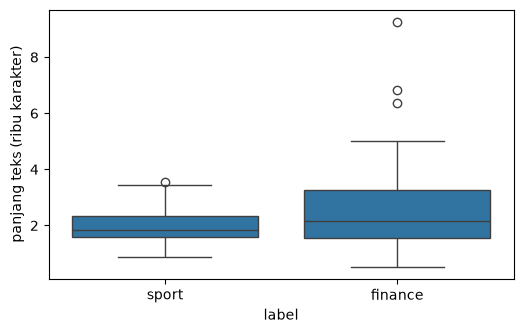

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(6, 3.5))
sns.boxplot(data=df, x="label", y=df["isi_berita"].str.len() / 1000, ax=ax)
ax.set_ylabel("panjang teks (ribu karakter)")
plt.show()

## Tahap 2: Pembersihan Format & Analisis Kebahasaan (Cleaning & Language)

### 2.1 Kualitas Teks: Deteksi Artefak Format & Karakter Non-ASCII
Pengecekan pertama di tingkat teks: karakter di luar ASCII standar (seperti huruf beraksen, emoji, atau tanda hubung non-breaking) dilacak di setiap artikel berita.

### 2.2 Normalisasi Karakter (Character Normalization)
Karakter khusus dinormalisasi: huruf beraksen dikembalikan ke bentuk dasar huruf Latin, spasi non-breaking diseragamkan, dan emoji disisihkan pada tahap pembersihan simbol.


In [6]:
def chars_outside_ascii(text):
    return sorted({c for c in str(text) if ord(c) > 127})

rows = []
for _, r in df.iterrows():
    extra = chars_outside_ascii(r["isi_berita"])
    if extra:
        rows.append({"id": r["id"], "label": r["label"], "karakter": " ".join(extra)})
pd.DataFrame(rows)

,id,label,karakter
0,16,sport,— 🇫 🇷 🏆
1,46,sport,ø
2,124,finance,€
3,141,finance,³


Artikel yang membawa karakter khusus diidentifikasi. Aksen muncul pada nama diri dan serapan, emoji pada kutipan cuitan, dan tanda hubung non-breaking pada beberapa artikel. Aksen dinormalisasi ke huruf dasar (nama tetap terbaca), tanda hubung non-breaking disamakan dengan tanda hubung biasa, dan emoji serta simbol lain dibuang pada tahap pembersihan simbol. Contoh sebelum dan sesudah:

In [7]:
import unicodedata

def normalize_letters(text):
    decomposed = unicodedata.normalize("NFD", text)
    text = "".join(c for c in decomposed if not unicodedata.combining(c))
    return text.replace("\u2011", "-").replace("\u2010", "-").replace("\u2013", "-").replace("\u2014", "-")

sample_ids = [r["id"] for r in rows[:6]] if rows else [1, 2, 3, 4, 5]
sample = df.set_index("id").loc[sample_ids, "isi_berita"]
pd.DataFrame({
    "id": sample.index,
    "sebelum": [t[:90] for t in sample],
    "sesudah": [normalize_letters(t)[:90] for t in sample],
})

,id,sebelum,sesudah
0,16,Badminton Prancis berjaya dalam Kejuaraan Duni...,Badminton Prancis berjaya dalam Kejuaraan Duni...
1,46,Febriana Dwipuji Kusuma/Meilysa Trias Puspita ...,Febriana Dwipuji Kusuma/Meilysa Trias Puspita ...
2,124,Puluhan ton emas milik Bank Sentral Belanda (D...,Puluhan ton emas milik Bank Sentral Belanda (D...
3,141,"Market Overview Di pasar saham, IHSG ditutup n...","Market Overview Di pasar saham, IHSG ditutup n..."


### 2.3 Penghitungan Artefak & Sumber Masalah (Artifact Counts & Sources)
Korpus diperiksa dalam dua kondisi: teks asli dan teks sesudah operasi naif (huruf kecil, angka serta simbol diganti spasi). Hal ini membuktikan bahwa pembersihan naif memecah kata majemuk menjadi serpihan token tanpa makna.


In [8]:
import re
from collections import Counter

def naive_tokens(text):
    return re.sub(r"[^a-z\s]", " ", text.lower()).split()

naive = [w for doc in df["isi_berita"] for w in naive_tokens(doc)]
naive_counts = Counter(naive)
single = {w: n for w, n in naive_counts.items() if len(w) == 1}
double = {w: n for w, n in naive_counts.items() if len(w) == 2}
total_naive = len(naive)

pd.DataFrame({
    "metrik": ["token total", "kata unik", "token satu huruf", "token dua huruf"],
    "jumlah": [total_naive, len(naive_counts), sum(single.values()), sum(double.values())],
    "proporsi": ["100%", f"{100 * len(naive_counts) / total_naive:.2f}%", f"{100 * sum(single.values()) / total_naive:.2f}%", f"{100 * sum(double.values()) / total_naive:.2f}%"],
})

,metrik,jumlah,proporsi
0,token total,60051,100%
1,kata unik,6344,10.56%
2,token satu huruf,245,0.41%
3,token dua huruf,2836,4.72%


Token satu dan dua huruf menyumbang hampir 5% dari total kemunculan token. Kedua kelompok inilah sumber utama pecahan kata tak bermakna.

### 2.4 Sensus & Analisis Token Satu Karakter (One-Letter Token Census)
Token satu huruf dihitung frekuensinya, lalu konteks kemunculannya di teks asli dianalisis secara objektif.


In [9]:
pd.DataFrame([{"huruf": w, "jumlah": n} for w, n in sorted(single.items(), key=lambda x: -x[1])])

,huruf,jumlah
0,i,44
1,d,40
2,s,32
3,m,22
4,a,21
5,y,14
6,u,12
7,b,12
8,h,12
9,p,9


Konteks di teks asli diambil untuk huruf-huruf dengan kemunculan terbanyak.

In [10]:
def context(texts, token, window=25):
    for text in texts:
        for m in re.finditer(r"(?<![A-Za-z])" + re.escape(token) + r"(?![A-Za-z])", text, re.IGNORECASE):
            start = max(0, m.start() - window)
            return text[start:m.end() + window].replace("\n", " ")
    return "-"

top_singles = [w for w, _ in sorted(single.items(), key=lambda x: -x[1])[:9]]
pd.DataFrame([{"huruf": w, "konteks": context(list(df["isi_berita"]), w)} for w in top_singles])

,huruf,konteks
0,i,et dari Nan Hsun Lin/Kai-i Wang. Keunggulan 7-...
1,d,"laga perdana di Lapangan D, Bali Beach Country..."
2,s,k Kedua Seri IV M-15 Men's World Tennis Champi...
3,m,s ke Babak Kedua Seri IV M-15 Men's World Tenn...
4,a,"abak Pertama di Lapangan A, Bali Beach Country..."
5,y,KU 11 Putra 1. Kean Alfa Y Warankiran - Makass...
6,u,Hasil FIP Promises Bali U-12 Putra: M. Rakha ...
7,b,"a, menghadapi juara grup B Matthieu Perchicot ..."
8,h,"aimana persiapan di hari H-nya itu, eksekusi d..."


Dari analisis konteks, tidak ada satu pun huruf tunggal yang berdiri sendiri sebagai kata mandiri: *x* berasal dari '3x3', *u* dari 'U-16/U-18', *i* dari angka romawi 'kuartal I', dan sebagainya. Oleh karena itu ditetapkan aturan: token satu huruf tidak dijadikan fitur (panjang minimum kata = 2 karakter).

### 2.5 Sensus & Analisis Token Dua Karakter (Two-Letter Token Census)
Dengan metode yang sama, seluruh token dua huruf diperiksa konteksnya untuk memisahkan kata tugas bahasa Indonesia dari singkatan teknis atau partikel asing.


In [11]:
rows = []
for w, n in sorted(double.items(), key=lambda x: -x[1]):
    if n >= 3:
        rows.append({"token": w, "jumlah": n, "konteks": context(list(df["isi_berita"]), w)})
pd.DataFrame(rows)

,token,jumlah,konteks
0,di,1250,"ing sesuai dengan target di Asian Games,"" ujar..."
1,ke,269,ar 20 pemain yang dibawa ke Asian Games 2026. ...
2,rp,258,"ilai 3.600 dolar AS atau Rp 63,5 juta, sementa..."
3,pt,190,"a juga Presiden Direktur PT Pembangunan Jaya, ..."
4,ya,107,"ai babak sejauh ini tapi ya sangat kecewa, tid..."
5,ia,104,"BWF, Selasa (25/8/2026). Ia di urutan teratas ..."
6,bi,66,Gubernur Bank Indonesia (BI) Destry Damayanti ...
7,as,44,"diah total 20 ribu dolar AS, Indonesia punya e..."
8,pb,40,b bulu tangkis Indonesia PB Jaya Raya merayaka...
9,ri,30,mpatan mengirim kado HUT RI ke-81 dari New Delhi.


Token dua huruf terbagi tiga kelas. Pertama, kata fungsi Indonesia yang berdiri sendiri (di, ke, ia, ya). Kedua, lambang, satuan, dan singkatan (rp rupiah, us dari US$, ri, pt, bi, ku singkatan “Kelompok Umur”, kg satuan, hr Harga Referensi, angka Romawi iv/ii/xi). Ketiga, partikel Inggris pada rentas yang dipertahankan (of pada Hall of Fame, vs pada pertandingan, up pada runner-up, on/to/in/ by pada kutipan). Kelas pertama dipisahkan secara objektif memakai daftar stopword bahasa Indonesia.

In [12]:
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

id_stopwords = set(StopWordRemoverFactory().get_stop_words())
tokens_2huruf = [w for w, n in double.items() if n >= 3]
(pd.DataFrame({"token": tokens_2huruf, "jumlah": [double[w] for w in tokens_2huruf], "stopword Indonesia": [w in id_stopwords for w in tokens_2huruf]})
 .sort_values("jumlah", ascending=False))

,token,jumlah,stopword Indonesia
1,di,1250,True
0,ke,269,True
11,rp,258,False
34,pt,190,False
13,ya,107,True
8,ia,104,True
43,bi,66,False
7,as,44,False
33,pb,40,False
31,ri,30,False


Hanya kata tugas sah (*di*, *ke*, *ia*, *ya*) yang dipertahankan, sedangkan satuan dan singkatan teknis disisihkan.

### 2.6 Deteksi Bahasa pada Tingkat Kalimat (Foreign Language Detection)
Setiap kalimat diperiksa proporsi bahasanya menggunakan pustaka `langid` guna mengidentifikasi keberadaan istilah atau kalimat berbahasa asing.


In [13]:
import langid

sentences, article_ids = [], []
for _, row in df.iterrows():
    parts = [p.strip() for p in re.split(r"(?<=[.!?])\s+|\n+", row["isi_berita"]) if p.strip()]
    sentences.extend(parts)
    article_ids.extend([row["id"]] * len(parts))

lang_labels = [langid.classify(s)[0] for s in sentences]
lang_counts = Counter(lang_labels)
(pd.DataFrame({"bahasa": list(lang_counts), "kalimat": list(lang_counts.values()), "proporsi": [f"{100 * k / len(sentences):.1f}%" for k in lang_counts.values()]})
 .sort_values("kalimat", ascending=False))

,bahasa,kalimat,proporsi
0,id,3140,77.8%
1,ms,619,15.3%
3,en,127,3.1%
2,jv,38,0.9%
8,es,21,0.5%
14,de,15,0.4%
16,pl,10,0.2%
6,tl,7,0.2%
7,eu,5,0.1%
18,rw,5,0.1%


Bahasa Indonesia mendominasi; label Melayu dan Inggris menyusul. Kalimat berlabel en yang panjangnya minimal 8 kata ditampilkan untuk melihat mana yang benar-benar prosa Inggris dan mana yang sekadar fragmen.

In [14]:
en_long = []
for s, lang, aid in zip(sentences, lang_labels, article_ids):
    if lang == "en" and len(s.split()) >= 8:
        en_long.append({"id": aid, "kalimat": s})
pd.DataFrame(en_long).assign(kalimat=lambda d: d["kalimat"].str[:96] + "...")

,id,kalimat
0,6,Leo Rolly Carnando/Daniel Marthin melaju ke ba...
1,16,"Take a bow, the first-ever world champions fro..."
2,82,Reza Pahlevi Isfahani Leo Rolly Carnando/Danie...
3,105,Daftar 13 Bank Tutup Periode Januari-September...
4,126,Daftar 13 Bank Tutup Periode Januari-September...
5,139,"Kemudian, dolar AS berhasil menguat terhadap d..."
6,157,Daftar 12 Bank Tutup Periode Januari-Agustus 2...
7,162,Daftar 12 Bank Tutup Periode Januari-Agustus 2...


Mayoritas kalimat terdeteksi sebagai bahasa Indonesia. Fragmen yang berlabel bahasa asing umumnya merupakan istilah teknis olahraga atau kutipan langsung yang dipertahankan apa adanya agar tidak merusak makna teks.

### 2.7 Pengujian Deteksi Tingkat Token (Per-Token Detection Test)
Pengujian per-token dilakukan untuk memastikan pustaka deteksi bahasa tidak salah mengklasifikasikan kosakata umum bahasa Indonesia.


In [15]:
probe = ["dan", "di", "ke", "dalam", "pada", "akan", "juga", "satu", "tim", "karena", "itu", "ini", "pemerintah", "sepak", "bola", "bank", "saham", "untuk"]
pd.DataFrame({"kata": probe, "hasil langid": [langid.classify(w)[0] for w in probe]})

,kata,hasil langid
0,dan,en
1,di,en
2,ke,en
3,dalam,en
4,pada,en
5,akan,en
6,juga,en
7,satu,en
8,tim,en
9,karena,en


langid memberi label Inggris pada kata Indonesia yang paling umum sekalipun (dan, di, ke, dalam, pada, akan), dan label acak untuk kata lain (saham → bahasa Ceko, untuk → Finlandia). Filter per token hanya akan membuang kata Indonesia sendiri.

Sebagai gantinya, kata asing pada kalimat Inggris yang panjang diperiksa: apakah benar kata serapan atau hanya nama diri.

In [16]:
token_in_en = Counter()
for s, lang in zip(sentences, lang_labels):
    if lang == "en" and len(s.split()) >= 8:
        token_in_en.update(re.findall(r"[A-Za-z]+", s.lower()))
corpus_words = Counter(
    w for t in df["isi_berita"] for w in re.findall(r"[A-Za-z]+", t.lower()))
cap_forms = Counter(
    w.lower() for t in df["isi_berita"] for w in re.findall(r"[A-Za-z]+", t) if w[0].isupper())
rows_en = []
for w, n_en in token_in_en.most_common(20):
    rows_en.append({"kata": w, "di kalimat en": n_en, "total korpus": corpus_words[w], "muncul kapital": cap_forms[w]})
pd.DataFrame(rows_en)

,kata,di kalimat en,total korpus,muncul kapital
0,daftar,4,25,9
1,bank,4,200,155
2,tutup,4,18,4
3,periode,4,44,4
4,januari,4,14,14
5,leo,2,37,37
6,rolly,2,10,10
7,carnando,2,10,10
8,daniel,2,39,39
9,marthin,2,9,9


Kandidat kata asing pada kalimat Inggris hampir semuanya nama diri yang bentuk kapitalnya konsisten — kolom “muncul kapital” menyamai “total korpus”; sisa baris hanyalah partikel Inggris pada kutipan yang dipertahankan. Istilah jurnalistik yang sudah mapan (season, game, runner-up, fans) dipakai sebagai leksikon baku media Indonesia; padanan Indonesianya sering sudah berdampingan (“juara dan runner-up”), sehingga menerjemahkannya tidak menambah informasi. Keputusan: tidak ada token yang diterjemahkan — seluruh konten asing dipertahankan.

## Tahap 3: Pelestarian Makna & Standardisasi Slang (Meaning Preservation)

### 3.1 Perlindungan Entitas Komposit, URL, & Simbol Bermakna
Sebelum tanda baca dan angka dihapus, entitas khusus seperti URL, satuan mata uang (Rp, USD), istilah alfanumerik (misal: *3x3*, *U-18*, *76ers*), dan angka Romawi diproteksi terlebih dahulu agar tidak terpotong menjadi serpihan huruf tak bermakna.


In [17]:
url_pattern = re.compile(r"(?:https?://|www\.|pic\.twitter\.com/)\S+")
alnum_pattern = re.compile(r"\b(?=[A-Za-z]*\d)[A-Za-z0-9][A-Za-z0-9.*-]*\b")
currency_pattern = re.compile(r"\bRp\d[\d.,]*\b|\bUS\$\d[\d.,]*\b|\b\$\d[\d.,]*\b|\bRp\b|\bUS\$\b")
roman_pattern = re.compile(r"\b(?:iii|iv|vi{0,3}|i[ivx]{0,2}|v|x{1,3}|xi{0,3})\b", re.IGNORECASE)

n_url = sum(len(url_pattern.findall(t)) for t in df["isi_berita"])
n_alnum = sum(len(alnum_pattern.findall(t)) for t in df["isi_berita"])
n_curr = sum(len(currency_pattern.findall(t)) for t in df["isi_berita"])
n_roman = sum(len(roman_pattern.findall(t)) for t in df["isi_berita"])

pd.DataFrame({
    "jenis": ["URL", "komposit alfanumerik dan angka", "lambang mata uang", "angka Romawi"],
    "kemunculan": [n_url, n_alnum, n_curr, n_roman],
    "contoh": ["pic.twitter.com/ZjxXtIycwl", "3x3, U-18, 76ers, 2026, GA-604", "Rp, US$", "IV, VIII, XI"],
})

,jenis,kemunculan,contoh
0,URL,1,pic.twitter.com/ZjxXtIycwl
1,komposit alfanumerik dan angka,3560,"3x3, U-18, 76ers, 2026, GA-604"
2,lambang mata uang,263,"Rp, US$"
3,angka Romawi,79,"IV, VIII, XI"


Angka Romawi lepas (IV, VIII, XI pada “Komisi XI”, “Wakil Rektor IV”) adalah penomoran, bukan term, dan ikut disisihkan bersama URL dan lambang mata uang. Efeknya terhadap token satu dan dua huruf diukur dengan membandingkan cacah naif dan cacah setelah proteksi, pembersihan simbol, serta panjang minimum 2.

In [18]:
def protect(text):
    text = url_pattern.sub(" ", text)
    text = currency_pattern.sub(" ", text)
    text = alnum_pattern.sub(" ", text)
    text = roman_pattern.sub(" ", text)
    return text.replace("\u2011", "-")

def clean_part1(text):
    text = normalize_letters(protect(text))
    text = re.sub(r"[^A-Za-z\s-]", " ", text)
    text = re.sub(r"-+", " ", text)
    return " ".join(w for w in text.split() if len(w) >= 2)

corpus_clean_1 = [clean_part1(t) for t in df["isi_berita"]]
tokens_1 = [w.lower() for doc in corpus_clean_1 for w in doc.split()]
counts_1 = Counter(tokens_1)

pd.DataFrame({
    "kondisi": ["naif (teks asli)", "setelah proteksi dan strip (min. 2 huruf)"],
    "token total": [total_naive, len(tokens_1)],
    "kata unik": [len(naive_counts), len(counts_1)],
    "token satu huruf": [sum(single.values()), sum(n for w, n in counts_1.items() if len(w) == 1)],
    "token dua huruf": [sum(double.values()), sum(n for w, n in counts_1.items() if len(w) == 2)],
})

,kondisi,token total,kata unik,token satu huruf,token dua huruf
0,naif (teks asli),60051,6344,245,2836
1,setelah proteksi dan strip (min. 2 huruf),59475,6310,0,2524


### 3.2 Penanganan Partikel dalam Nama Diri
Partikel penghubung dalam nama resmi (seperti *of* pada *Hall of Fame*) diatur sedemikian rupa agar kata inti namanya tetap terpelihara dalam korpus.


In [19]:
pd.DataFrame([{"pola": w, "konteks": context(list(df["isi_berita"]), w)} for w in ["of", "la", "de"]])

,pola,konteks
0,of,"n gaya hidup,"" kata Head of Marketing AQUA Ele..."
1,la,tentukan di luar negeri. la menilai praktik te...
2,de,rmawan U-14 Putri: Calia De Heyn & Namu Steenb...


### 3.3 Sensus Nama Diri & Kata Berkapital (Proper Nouns Census)
Mendeteksi dan menghitung frekuensi kemunculan nama tokoh, institusi, dan klub di tengah kalimat untuk menjamin entitas penting tidak hilang.


In [20]:
def mid_sentence(text, pos):
    i = pos - 1
    while i >= 0 and text[i] in ' \n\t"\'":(':
        i -= 1
    return i >= 0 and text[i] not in '.!?;:(\u2013\u2014'

name_counts = Counter()
for text in df["isi_berita"]:
    for m in re.finditer(r"[A-Za-z]+", text):
        w = m.group(0)
        if (len(w) >= 3 and w[0].isupper() and mid_sentence(text, m.start())):
            name_counts[w.lower()] += 1

pd.DataFrame({
    "metrik": ["nama diri unik", "kemunculan total", "nama dengan >= 3 kemunculan"],
    "jumlah": [len(name_counts), sum(name_counts.values()), sum(1 for n in name_counts.values() if n >= 3)],
})

,metrik,jumlah
0,nama diri unik,2331
1,kemunculan total,12317
2,nama dengan >= 3 kemunculan,877


In [21]:
pd.DataFrame([{"nama": w, "kemunculan": n} for w, n in name_counts.most_common(15)])

,nama,kemunculan
0,indonesia,438
1,dunia,220
2,kejuaraan,191
3,bank,154
4,ojk,111
5,bpr,97
6,jakarta,94
7,nita,92
8,jonatan,83
9,fikri,83


### 3.4 Standardisasi Kata Tidak Baku / Slang (Slang Normalization)
Menggunakan kamus normalisasi untuk mengganti ragam kata tidak baku/bahasa percakapan menjadi bentuk baku bahasa Indonesia secara kontekstual.


In [22]:
from indoNLP.preprocessing import replace_slang

slang_hit = Counter()
cap_hit = Counter()
for text in df["isi_berita"]:
    for m in re.finditer(r"[A-Za-z]+", text):
        w = m.group(0)
        if replace_slang(w.lower()) != w.lower():
            slang_hit[w.lower()] += 1
            if w[0].isupper() and mid_sentence(text, m.start()):
                cap_hit[w.lower()] += 1

pd.DataFrame({
    "metrik": ["token kena kamus", "kemunculan berubah", "kemunculan nama diri (kapital tengah kalimat)"],
    "jumlah": [len(slang_hit), sum(slang_hit.values()), sum(cap_hit.values())],
})

,metrik,jumlah
0,token kena kamus,70
1,kemunculan berubah,399
2,kemunculan nama diri (kapital tengah kalimat),218


#### A. Tabrakan Kamus Slang dengan Nama Diri / Istilah Resmi
Mengevaluasi kata-kata yang berisiko keliru distandarisasi (misal: istilah olahraga seperti *slam dunk* atau nama produk) agar tidak diubah secara sembarangan.


In [23]:
rows_slang = []
for w in sorted(slang_hit, key=lambda x: -cap_hit[x]):
    rows_slang.append({"token": w, "kemunculan": slang_hit[w], "kapital tengah": cap_hit[w], "padanan kamus": replace_slang(w)})
pd.DataFrame(rows_slang[:15])

,token,kemunculan,kapital tengah,padanan kamus
0,m,22,21,sama
1,s,32,19,si
2,d,40,17,di
3,tp,15,15,tapi
4,yoo,13,13,ya
5,mbg,14,13,mbak
6,u,12,12,lu
7,baek,18,12,baik
8,so,9,9,sok
9,de,10,8,deh


#### B. Pengecualian & Verifikasi Konteks Istilah Khusus
Memeriksa konteks istilah khusus media massa guna menetapkan daftar pengecualian (*blacklist replacement*).


In [24]:
test_words = [w for w in ["dunk", "slam", "minta", "fans", "pala", "masukin", "ganda", "indonesia"] if w in corpus_words]
pd.DataFrame([{"kata": w, "konteks": context(list(df["isi_berita"]), w)} for w in test_words[:6]])

,kata,konteks
0,slam,"Juara Grand Slam tujuh kali, Carlos Alcar"
1,ganda,beberapa wakil di nomor ganda putra. Sabar Ka...
2,indonesia,Persatuan Bulutangkis Indonesia (PBSI) baru sa...


#### C. Filter Final Standardisasi Slang
Menerapkan saringan akhir sehingga hanya kata gaul yang benar-benar tidak baku yang diganti ke padanan kata baku bahasa Indonesia.


In [25]:
excluded_slang = {"dunk", "slam", "minta", "fans", "pala", "masukin"}
slang_changes = Counter()

def guarded_replace(text):
    changes = []
    for m in re.finditer(r"[A-Za-z]+", text):
        w = m.group(0)
        repl = replace_slang(w.lower())
        if repl == w.lower() or w.lower() in excluded_slang:
            continue
        before = text[max(0, m.start() - 6):m.start()]
        after = text[m.end():m.end() + 6]
        near_digit = bool(re.search(r"\d", before + after))
        byline = bool(re.search(r"\(\w{2,6}/\w{2,6}\)", text[m.start() - 6:m.end() + 6]))
        looks_name = (w.isupper() or any(c.isupper() for c in w[1:]) or 
                      (w[:1].isupper() and w[1:].islower() and mid_sentence(text, m.start())))
        two_letter = len(w) <= 2 and w.lower() not in id_stopwords
        if not (near_digit or byline or looks_name or two_letter):
            changes.append((m.start(), m.end(), repl))
            slang_changes[w.lower()] += 1
            
    out = list(text)
    for s, e, r in reversed(changes):
        out[s:e] = list(r)
    return "".join(out)

def clean_full(text):
    text = normalize_letters(protect(text))
    text = guarded_replace(text)
    text = re.sub(r"[^A-Za-z\s-]", " ", text)
    text = re.sub(r"-+", " ", text)
    words = [w for w in text.split() if len(w) >= 2]
    return " ".join(w for w in words if not (len(w) == 2 and w.lower() not in id_stopwords))

final_docs = [clean_full(t).split() for t in df["isi_berita"]]
post_counts = Counter(w.lower() for doc in final_docs for w in doc)

applied_rows = []
for w, cnt in sorted(slang_changes.items()):
    applied_rows.append({"kata": w, "diubah": cnt, "padanan": replace_slang(w), "di korpus akhir": post_counts.get(replace_slang(w), 0)})
pd.DataFrame(applied_rows)

,kata,diubah,padanan,di korpus akhir
0,abis,1,habis,9
1,aja,11,saja,77
2,baek,6,baik,101
3,bener,1,benar,22
4,beneran,1,benaran,1
5,dah,1,deh,1
6,dapet,1,dapat,135
7,gimana,6,bagaimana,34
8,gini,3,begini,4
9,gitu,16,begitu,42


#### D. Token yang Dilindungi / Dipertahankan Utuh
Menampilkan daftar token khusus yang berhasil dilindungi dari pengubahan.


In [26]:
blocked_rows = []
for w in sorted(post_counts):
    if replace_slang(w) != w:
        blocked_rows.append({"kata": w, "kemunculan": post_counts[w], "padanan kamus": replace_slang(w)})
pd.DataFrame(blocked_rows)

,kata,kemunculan,padanan kamus
0,baek,12,baik
1,dhe,1,deh
2,indo,4,indonesia
3,jing,6,anjing
4,mbg,14,mbak
5,ngarang,1,mengarang
6,pgn,4,pengin
7,sam,5,sama
8,slam,2,salam
9,sma,2,sama


### 3.5 Pembentukan Korpus Bersih Akhir (Final Clean Corpus)
Menyatukan seluruh proses pembersihan, proteksi nama diri, dan standardisasi menjadi korpus dokumen berita yang telah bersih dan terstandar.


In [27]:
all_final = [w.lower() for doc in final_docs for w in doc]
final_counts = Counter(all_final)
label_counts = Counter()
for doc, label in zip(final_docs, df["label"]):
    label_counts[label] += len(doc)
two_letter_final = {w: n for w, n in final_counts.items() if len(w) == 2}

pd.DataFrame({
    "metrik": ["token total", "kata unik", "token dua huruf tersisa", "token per label"],
    "jumlah": [sum(final_counts.values()), len(final_counts), ", ".join(f"{w}: {final_counts[w]}" for w in sorted(two_letter_final)), ", ".join(f"{k}: {v}" for k, v in label_counts.items())],
})

,metrik,jumlah
0,token total,58684
1,kata unik,6202
2,token dua huruf tersisa,"di: 1250, ia: 104, ke: 269, oh: 3, ya: 107"
3,token per label,"sport: 26921, finance: 31763"


## Tahap 4: Representasi VSM, TF-IDF, dan Reduksi Dimensi PCA (Representation & Reduction)

### 4.1 Analisis Kosakata Unik Berdasarkan Kategori Berita
Mengekstrak dan mengelompokkan kosakata khas yang dominan muncul pada masing-masing kategori (*Sport* dan *Finance*).


In [28]:
sport_words = {w for doc, lbl in zip(final_docs, df["label"]) if lbl == "sport" for w in doc}
finance_words = {w for doc, lbl in zip(final_docs, df["label"]) if lbl == "finance" for w in doc}

pd.DataFrame({
    "label": ["sport", "finance", "dipakai kedua label"],
    "kata unik": [len(sport_words), len(finance_words), len(sport_words & finance_words)],
})

,label,kata unik
0,sport,3516
1,finance,5154
2,dipakai kedua label,1393


### 4.2 Kata Paling Sering Muncul di Seluruh Korpus (Most Frequent Words)
Menghitung frekuensi kemunculan seluruh kata pada korpus gabungan untuk melihat term-term yang paling berpengaruh.


In [29]:
pd.DataFrame([{"kata": w, "kemunculan": n} for w, n in final_counts.most_common(30)])

,kata,kemunculan
0,di,1250
1,yang,1152
2,dan,1078
3,dengan,614
4,untuk,583
5,dari,539
6,ini,535
7,indonesia,469
8,dalam,463
9,pada,435


### 4.3 Representasi Matriks Ruang Vektor (VSM TF-IDF)
Korpus berita bersih ditransformasikan ke dalam representasi numerik menggunakan pembobotan *Term Frequency - Inverse Document Frequency* (TF-IDF):
1. **Matriks TF-IDF Penuh**: Memuat seluruh 6.202 kata unik sebagai fitur leksikal.
2. **Matriks TF-IDF Reduksi Leksikal (500 Dimensi)**: Memilih 500 fitur kata terbaik berdasarkan frekuensi kemunculan tertinggi (`max_features=500`).


In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. TF-IDF Penuh (Belum Direduksi: 6.202 fitur kata unik)
vec_full = TfidfVectorizer(token_pattern=r"(?u)\b\w\w+\b")
X_full = vec_full.fit_transform([" ".join(doc) for doc in final_docs])

# 2. TF-IDF Reduksi Dimensi Leksikal (500 fitur kata terbaik)
vectorizer = TfidfVectorizer(max_features=500, token_pattern=r"(?u)\b\w\w+\b")
X = vectorizer.fit_transform([" ".join(doc) for doc in final_docs])

pd.DataFrame({
    "matriks": ["TF-IDF Penuh (Belum Direduksi)", "TF-IDF Reduksi (500 Dimensi)"],
    "jumlah dokumen (baris)": [X_full.shape[0], X.shape[0]],
    "jumlah fitur kata (kolom)": [X_full.shape[1], X.shape[1]],
    "entri bukan nol (nnz)": [X_full.nnz, X.nnz]
})

,metrik,nilai
0,jumlah dokumen (baris),200
1,fitur kata hasil reduksi (kolom),500
2,entri bukan nol (nnz),17016


### 4.4 Penyimpanan Matriks TF-IDF Beserta Kolom Label (Input Tugas 3)
Kedua matriks TF-IDF digabungkan dengan **kolom `label` di kolom paling akhir** (`sport` dan `finance`), lalu disimpan ke direktori `Output/` (`tfidf_berita.csv` dan `tfidf_berita_500.csv`). Berkas inilah yang menjadi masukan utama pada pemodelan **Tugas 3**.


In [31]:
import scipy.sparse as sp
import os

# Memastikan folder penyimpanan tersedia
os.makedirs('data', exist_ok=True)
os.makedirs('Output', exist_ok=True)

# 1. Simpan data pendukung sparse
sp.save_npz('data/tfidf_sparse.npz', X)
pd.Series(vectorizer.get_feature_names_out()).to_csv('data/tfidf_features.txt', index=False, header=False)
pd.DataFrame({'id': df['id'], 'label': df['label']}).to_csv('data/tfidf_docs.csv', index=False)

# 2. DataFrame TF-IDF Penuh (Belum Direduksi: 6.202 kata + kolom label di akhir)
raw_full_features = list(vec_full.get_feature_names_out())
features_full = [f if f != 'label' else 'kata_label' for f in raw_full_features]
df_tfidf_full = pd.DataFrame(
    X_full.toarray(),
    columns=features_full,
    index=[f'Dokumen_{i}' for i in df['id']]
)
df_tfidf_full['label'] = df['label'].values

# Simpan TF-IDF Penuh ke Output/tfidf_berita.csv
df_tfidf_full.to_csv('Output/tfidf_berita.csv')
if os.path.exists('../Output'):
    try:
        df_tfidf_full.to_csv('../Output/tfidf_berita.csv')
    except Exception:
        pass

# 3. DataFrame TF-IDF Reduksi (500 kata + kolom label di akhir)
df_tfidf_500 = pd.DataFrame(
    X.toarray(),
    columns=vectorizer.get_feature_names_out(),
    index=[f'Dokumen_{i}' for i in df['id']]
)
df_tfidf_500['label'] = df['label'].values

# Simpan TF-IDF Reduksi ke Output/tfidf_berita_500.csv
df_tfidf_500.to_csv('Output/tfidf_berita_500.csv')
if os.path.exists('../Output'):
    try:
        df_tfidf_500.to_csv('../Output/tfidf_berita_500.csv')
    except Exception:
        pass

print('1. Bentuk TF-IDF Penuh (tfidf_berita.csv):', df_tfidf_full.shape, '| Kolom terakhir:', df_tfidf_full.columns[-1])
print('2. Bentuk TF-IDF Reduksi (tfidf_berita_500.csv):', df_tfidf_500.shape, '| Kolom terakhir:', df_tfidf_500.columns[-1])


Bentuk matriks akhir (baris, kolom): (200, 501)
Nama kolom terakhir: label


,abadi,ada,adalah,administratif,agar,yakni,yang,label
Dokumen_1,0.0,0.031322,0.072805,0.0,0.0,0.046452,0.089231,sport
Dokumen_2,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.039018,sport
Dokumen_3,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,sport
Dokumen_4,0.0,0.000000,0.082873,0.0,0.0,0.000000,0.101571,sport
Dokumen_5,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.076874,sport


### 4.5 Reduksi Dimensi dengan Principal Component Analysis (PCA)
Mereduksi ruang vektor 500 dimensi menjadi **2 komponen utama (PC1 dan PC2)** menggunakan PCA untuk memvisualisasikan keterpisahan antarkelas berita secara geometris.


In [32]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
Z = pca.fit_transform(X.toarray())
evr = pca.explained_variance_ratio_

pd.DataFrame({
    "komponen": ["PC1", "PC2", "jumlah"],
    "proporsi varians": [f"{evr[0]:.4f}", f"{evr[1]:.4f}", f"{evr.sum():.4f}"],
})

,komponen,proporsi varians
0,PC1,0.0638
1,PC2,0.0415
2,jumlah,0.1053


### 4.6 Visualisasi Proyeksi 2 Dimensi PCA (PC1 vs PC2)
Memetakan posisi dokumen *Sport* dan *Finance* pada bidang 2D hasil proyeksi PCA untuk mengamati derajat keterpisahan antarkategori.


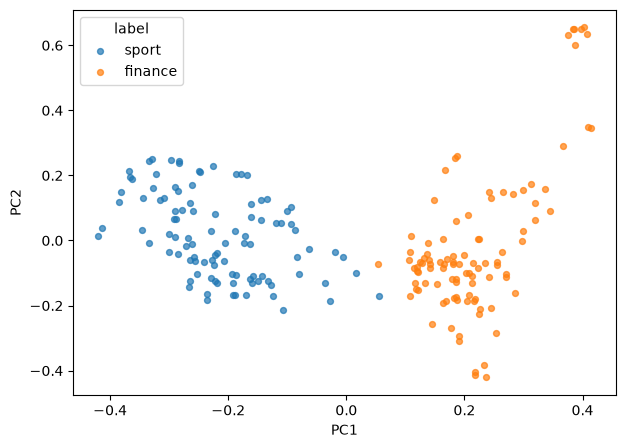

In [33]:
fig, ax = plt.subplots(figsize=(7, 5))
for label, color in [("sport", "#1f77b4"), ("finance", "#d62728")]:
    mask = (df["label"] == label).to_numpy()
    ax.scatter(Z[mask, 0], Z[mask, 1], s=18, alpha=0.7, label=label)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend(title="label")
plt.show()

## 5. Kesimpulan & Ringkasan Pipeline Tugas 2
Proses pra-pemrosesan teks telah berhasil mengubah 200 artikel mentah menjadi korpus bersih, matriks TF-IDF siap latih, dan representasi 2D PCA. Ringkasan angka hasil pengolahan:


In [34]:
pd.DataFrame({
    "metrik": [
        "dokumen awal", 
        "token bersih", 
        "kata unik total", 
        "fitur TF-IDF (hasil reduksi leksikal)", 
        "kolom target (kategori)",
        "varians dua komponen PCA", 
        "artefak yang disisihkan"
    ],
    "nilai": [
        len(df), 
        sum(final_counts.values()), 
        len(final_counts), 
        X.shape[1], 
        "sport & finance (kolom terakhir)",
        f"{evr.sum():.1%}",
        f"URL {n_url}, mata uang {n_curr}, komposit {n_alnum}, romawi {n_roman}"
    ],
})

,metrik,nilai
0,dokumen awal,200
1,token bersih,58684
2,kata unik total,6202
3,fitur TF-IDF (hasil reduksi leksikal),500
4,kolom target (kategori),sport & finance (kolom terakhir)
5,varians dua komponen PCA,10.5%
6,artefak yang disisihkan,"URL 1, mata uang 263, komposit 3560, romawi 79"
